# Paths

In [4]:
DATA_PATH = "/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/" 

ERA5_DIR = DATA_PATH+"unziped/ERA5_Cropped/"  # Folder with both pressure and single level files
WRF_DIR = DATA_PATH+"unziped/WRF_2km/"

ERA5_INTERPOLATED_DIR = DATA_PATH+"ERA5_interpolated/"
ERA5_WRF_COMBINED_DIR = DATA_PATH+ "ERA5_WRF_combined/"
ERA5_WRF_COMBINED_CONCATENATED_DIR = DATA_PATH + "ERA5_WRF_combined_concatenated/"

STAT_DIR = DATA_PATH + "stats/"

# Load regression model

# Load diffusion model

## Load model

In [2]:
ls -lh /app/outputs/checkpoints_diffusion/

total 1.3G
-rw-r--r-- 1 root root 44M Sep 23 14:40 EDMPrecondSuperResolution.0.145000.mdlus
-rw-r--r-- 1 root root 44M Sep 23 14:53 EDMPrecondSuperResolution.0.150016.mdlus
-rw-r--r-- 1 root root 44M Sep 23 15:06 EDMPrecondSuperResolution.0.155008.mdlus
-rw-r--r-- 1 root root 44M Sep 23 15:19 EDMPrecondSuperResolution.0.160000.mdlus
-rw-r--r-- 1 root root 44M Sep 23 15:32 EDMPrecondSuperResolution.0.165016.mdlus
-rw-r--r-- 1 root root 44M Sep 23 15:45 EDMPrecondSuperResolution.0.170008.mdlus
-rw-r--r-- 1 root root 44M Sep 23 15:58 EDMPrecondSuperResolution.0.175000.mdlus
-rw-r--r-- 1 root root 44M Sep 23 16:12 EDMPrecondSuperResolution.0.180016.mdlus
-rw-r--r-- 1 root root 44M Sep 23 16:25 EDMPrecondSuperResolution.0.185008.mdlus
-rw-r--r-- 1 root root 44M Sep 23 16:38 EDMPrecondSuperResolution.0.190000.mdlus
-rw-r--r-- 1 root root 81M Sep 23 14:40 checkpoint.0.145000.pt
-rw-r--r-- 1 root root 81M Sep 23 14:53 checkpoint.0.150016.pt
-rw-r--r-- 1 root root 81M Sep 23 15:06 checkpoint.0.

In [1]:
import os
import torch
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution
from physicsnemo.launch.utils.checkpoint import load_checkpoint

# Paths configuration
checkpoint_dir = "/app/outputs/checkpoints_diffusion"  # Directory where model checkpoints are stored
checkpoint_index = 190000  # Specific checkpoint number to load (from training logs)

# Model Initialization Parameters
# These arguments come from the training config YAML file
model_args = {
    # Number of additional grid channels for positional/conditional information
    # From model_args.N_grid_channels in training config
    "N_grid_channels": 4,
    
    # Type of positional embedding grid (sinusoidal, learned, etc.)
    # From model_args.gridtype in training config
    "gridtype": "sinusoidal",
    
    # Type of embedding for diffusion timesteps/noise levels
    # From model_args.embedding_type in training config
    "embedding_type": "zero",
    
    # Base number of channels in the model (scaled by channel_mult)
    # From model_args.model_channels in training config
    "model_channels": 64,
    
    # Channel multipliers for different resolution levels
    # [1, 2, 2] means: 64, 128, 128 channels at different resolutions
    # From model_args.channel_mult in training config
    "channel_mult": [1, 2, 2],
    
    # Resolutions at which to apply attention layers
    # From model_args.attn_resolutions in training config
    "attn_resolutions": [16],
    
    # Minimum noise level for diffusion process
    # Default value for EDM framework
    "sigma_min": 0.0,
    
    # Maximum noise level for diffusion process
    # Default value for EDM framework
    "sigma_max": 1.0,
    
    # Data standard deviation scaling factor
    # Default value for EDM framework
    "sigma_data": 0.5,
    
    # Type of UNet architecture being used
    # From model_args.model_type in training config
    "model_type": "SongUNetPosEmbd",
}

# Create the EDM Super-Resolution model
model = EDMPrecondSuperResolution(
    # Input image resolution (448x448)
    # Should match the resolution used during training
    img_resolution=440,
    
    # Number of input channels:
    # - 14: From input_variables in dataset config (t_850, t_500, z_850, etc.)
    # - 4: From N_grid_channels (positional/conditional information)
    # - 4: Likely from hr_mean_conditioning (2 output vars × 2 for mean/std)
    # Total = 22 channels (14 + 4 + 4)
    img_in_channels=22,
    
    # Number of output channels:
    # - 2: Matches output_variables in dataset config (U10, V10)
    img_out_channels=2,
    
    # Pass all other model configuration parameters
    **model_args,
)

# Load the pre-trained checkpoint
epoch = load_checkpoint(
    path=checkpoint_dir,  # Directory containing checkpoints
    models=model,        # Model to load weights into
    epoch=checkpoint_index,  # Checkpoint number to load
    device="cuda",       # Load onto GPU (use "cpu" if no GPU available)
    # strict=False       # Uncomment to ignore mismatched keys (not recommended)
)

print(f"Model loaded successfully from epoch {epoch}")

# Set the model to evaluation mode (important for inference)
model.eval()

`DistributedManager` not initialized already. Initializing now, but this might lead to unexpected errors
/app/physicsnemo/distributed/manager.py:415: UserWarning: Could not initialize using ENV, SLURM or OPENMPI methods. Assuming this is a single process job
  warn(


Model loaded successfully from epoch 190000


EDMPrecondSuperResolution(
  (model): SongUNetPosEmbd(
    (enc): ModuleDict(
      (440x440_conv): Conv2d()
      (440x440_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (440x440_block1): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (440x440_block2): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (440x440_block3): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (220x220_down): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
 

## Inspect model

In [6]:
import inspect
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution

# Print the forward method signature
print(inspect.signature(EDMPrecondSuperResolution.forward))

# Or for more details:
print(inspect.getsource(EDMPrecondSuperResolution.forward))

(self, x: torch.Tensor, img_lr: torch.Tensor, sigma: torch.Tensor, force_fp32: bool = False, **model_kwargs: dict) -> torch.Tensor
    def forward(
        self,
        x: torch.Tensor,
        img_lr: torch.Tensor,
        sigma: torch.Tensor,
        force_fp32: bool = False,
        **model_kwargs: dict,
    ) -> torch.Tensor:
        """
        Forward pass of the EDMPrecondSuperResolution model wrapper.

        This method applies the EDM preconditioning to compute the denoised image
        from a noisy high-resolution image and low-resolution conditioning image.

        Parameters
        ----------
        x : torch.Tensor
            Noisy high-resolution image of shape (B, C_hr, H, W). The number of
            channels `C_hr` should be equal to `img_out_channels`.
        img_lr : torch.Tensor
            Low-resolution conditioning image of shape (B, C_lr, H, W). The number
            of channels `C_lr` should be equal to `img_in_channels`.
        sigma : torch.Tensor

In [7]:
import torch

# Correct channel dimensions accounting for positional embeddings
batch_size = 1
main_channels = 18 # 16+2
hr_channels = 2  # U10/V10 output
height = width = 440

# Create properly sized dummy tensors
dummy_x = torch.randn(batch_size, hr_channels, height, width)  # High-res (2 channels)
dummy_img_lr = torch.randn(batch_size, main_channels, height, width)  # Low-res (18 channels)
sigma = torch.tensor([1.0])  # Noise level

# Run inference
with torch.no_grad():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dummy_x = dummy_x.to(device)
    dummy_img_lr = dummy_img_lr.to(device)
    model = model.to(device)
    sigma = sigma.to(device)
    
    try:
        output = model(x=dummy_x, img_lr=dummy_img_lr, sigma=sigma)
        print("Success! Output shape:", output.shape)
    except Exception as e:
        print("Failed:", str(e))

Success! Output shape: torch.Size([1, 2, 440, 440])


/app/physicsnemo/models/diffusion/layers.py:712: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


## Test diffusion

In [5]:
import xarray as xr
import torch
import numpy as np
import json
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

def get_data(data_path, sample_idx):
    # Open the dataset
    input_group = xr.open_dataset(data_path, group="input")
    output_group = xr.open_dataset(data_path, group="output")
    
    # Select the first sample for inference
    input_data = input_group.isel(sample=sample_idx)
    output_data = output_group.isel(sample=sample_idx)
    return input_data, output_data
    
def simulate_regression(output_data, noise_std=0.1, jitter_std=0.05, kernel_size=5):
    """
    Simulate regression by smoothing the data, adding noise, and applying jitter.

    Parameters:
    ----------
    output_data : dict
        Dictionary containing regression output data with keys like "U10" and "V10".
    noise_std : float, optional
        Standard deviation of the Gaussian noise to add, by default 0.1.
    jitter_std : float, optional
        Standard deviation of the jitter multiplier, by default 0.05.
    kernel_size : int, optional
        Size of the Gaussian smoothing kernel, by default 5.

    Returns:
    -------
    torch.Tensor
        Simulated regression data of shape (1, 2, H, W).
    """
    # Extract data and convert to PyTorch tensors
    u10 = torch.tensor(output_data["U10"].values, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W)
    v10 = torch.tensor(output_data["V10"].values, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W)

    # Concatenate along the channel dimension
    data = torch.cat((u10, v10), dim=1)  # Shape: (1, 2, H, W)

    # Apply Gaussian smoothing
    kernel = torch.ones((2, 1, kernel_size, kernel_size), dtype=torch.float32) / (kernel_size ** 2)  # Create 2 filters
    kernel = kernel.to(data.device)
    smoothed_data = F.conv2d(data, kernel, padding=kernel_size // 2, groups=2)  # Shape: (1, 2, H, W)

    # Add Gaussian noise
    noise = torch.randn_like(smoothed_data) * noise_std
    noisy_data = smoothed_data + noise

    # Apply jitter (pixel-wise random multiplier)
    jitter = 1 + torch.randn_like(noisy_data) * jitter_std
    simulated_data = noisy_data * jitter

    return simulated_data

    
# 2. Normalization functions
def normalize(data, var_name, stats):
    mean = stats["input"][var_name]["mean"]
    std = stats["input"][var_name]["std"]
    return (data - mean) / std

def denormalize(data, var_name, stats):
    mean = stats["output"][var_name]["mean"]
    std = stats["output"][var_name]["std"]
    return (data * std) + mean

def diffuse(model, input_data, stats, output_regression, iteration):

    # 3. Prepare input variables (all 18 total channels)
    selected_vars = [
        't_850', 't_500', 'z_850', 'z_500',  # 4 variables
        'u_850', 'u_500', 'v_850', 'v_500',  # +4 = 8
        'u10', 'v10', 't2m', 'd2m',          # +4 = 12
        "skt", "sp", "tcwv", "tp"            # +4 = 16
    ]

    # Stack and normalize input variables
    input_stack = []
    for var in selected_vars:
        var_data = input_data[var].values
        var_norm = normalize(var_data, var, stats)
        input_stack.append(var_norm)

    input_array = np.stack(input_stack, axis=0)  # Shape: (16, 440, 440)
    input_tensor = torch.from_numpy(input_array).float().unsqueeze(0)  # (1, 16, 440, 440)

    # 4. Prepare grid channels (4 channels as per config)
    # grid_channels = torch.zeros(1, 4, 440, 440)  # Batch of 4 grid channels
    
    # 5. Prepare conditioning (2 channels - means of U10/V10 only)
    conditioning = torch.zeros(1, 2, 440, 440)
    conditioning[:, 0] = stats["output"]["U10"]["mean"]  # U10 mean
    conditioning[:, 1] = stats["output"]["V10"]["mean"]  # V10 mean

    # 6. Combine all inputs (16 vars + 2 conditioning = 18 channels) + 4 grid are not added 
    # The model will add 6 positional channels internally (18 + 6 = 24)
    # low_res_input = torch.cat([input_tensor, grid_channels, conditioning], dim=1)
    low_res_input = torch.cat([input_tensor, conditioning], dim=1)
    
    # 8. Run inference
    with torch.no_grad():
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        output_regression = output_regression.to(device)
        low_res_input = low_res_input.to(device)
        model = model.to(device)
        
        # Prepare noise level (sigma)
        sigma = torch.tensor([1.0], device=device)

        output_diffusion = model(x=output_regression, img_lr=low_res_input, sigma=sigma)
        print(1)
        if iteration>1:
            for i in range(iteration-1):
                print(i+2)
                output_diffusion =  model(x=output_diffusion, img_lr=low_res_input, sigma=sigma)
    return output_diffusion

def post_process(output_diffuse):
    # 9. Process output_diffuse (U10 and V10)
    u10_pred = output_diffuse[0, 0]  # First output_diffuse channel
    v10_pred = output_diffuse[0, 1]  # Second output_diffuse channel
    
    u10_denorm = denormalize(u10_pred, "U10", stats)
    v10_denorm = denormalize(v10_pred, "V10", stats)
    return u10_denorm, v10_denorm
    
def plot_results_xarray(output_regression, output_diffuse, output_data, stats):
    """
    Plot results using xarray with a structured dataset containing 'type' dimension.
    Includes residuals for regression and diffusion.
    """
    # Post-process predictions
    u10_diffuse, v10_diffuse = post_process(output_diffuse)
    u10_regression = output_regression[0, 0, :, :].cpu().numpy()  # Extract U10 from regression
    v10_regression = output_regression[0, 1, :, :].cpu().numpy()  # Extract V10 from regression
    
    # Get ground truth
    u10_true = output_data["U10"].values
    v10_true = output_data["V10"].values

    # Calculate residuals
    u10_residual_regression = u10_regression - u10_true
    v10_residual_regression = v10_regression - v10_true
    u10_residual_diffusion = u10_diffuse - u10_true
    v10_residual_diffusion = v10_diffuse - v10_true

    # Print comparison
    print("U10 Prediction vs Ground Truth:")
    print(f"Diffuse Pred mean: {u10_diffuse.mean():.4f}, True mean: {u10_true.mean():.4f}")
    print(f"Diffuse Pred std: {u10_diffuse.std():.4f}, True std: {u10_true.std():.4f}")
    print(f"Regression Pred mean: {u10_regression.mean():.4f}")
    print(f"Regression Pred std: {u10_regression.std():.4f}")
    
    print("\nV10 Prediction vs Ground Truth:")
    print(f"Diffuse Pred mean: {v10_diffuse.mean():.4f}, True mean: {v10_true.mean():.4f}")
    print(f"Diffuse Pred std: {v10_diffuse.std():.4f}, True std: {v10_true.std():.4f}")
    print(f"Regression Pred mean: {v10_regression.mean():.4f}")
    print(f"Regression Pred std: {v10_regression.std():.4f}")
    
    # Get spatial dimensions
    y_dim, x_dim = u10_diffuse.shape
    
    # Create datasets with 'type' dimension
    # Dataset for U10
    ds_u10 = xr.Dataset({
        'U10': (['type', 'y', 'x'], [u10_regression, u10_diffuse, u10_true]),
        'Residual U10': (['type', 'y', 'x'], [u10_residual_regression, u10_residual_diffusion, np.zeros_like(u10_true)])
    }, coords={
        'type': ['output_regression', 'output_diffusion', 'ground_truth'],
        'y': range(y_dim),
        'x': range(x_dim)
    })
    
    # Dataset for V10
    ds_v10 = xr.Dataset({
        'V10': (['type', 'y', 'x'], [v10_regression, v10_diffuse, v10_true]),
        'Residual V10': (['type', 'y', 'x'], [v10_residual_regression, v10_residual_diffusion, np.zeros_like(v10_true)])
    }, coords={
        'type': ['output_regression', 'output_diffusion', 'ground_truth'],
        'y': range(y_dim),
        'x': range(x_dim)
    })
    
    # Plot U10 dataset
    print("\n=== U10 Wind Component ===") 
    ds_u10.U10.plot(
        col='type',  # Facet by prediction type
        col_wrap=3,
        cmap='coolwarm',
        robust=True,
        figsize=(15, 5),
    )
    plt.suptitle('U10 Wind Component - Regression vs Diffusion vs Ground Truth', y=1.02)
    plt.show()
    
    # # Plot Residual U10
    # print("\n=== Residual U10 ===")
    # ds_u10['Residual U10'].plot(
    #     col='type',
    #     col_wrap=3,
    #     cmap='coolwarm',
    #     robust=True,
    #     figsize=(15, 5),
    # )
    # plt.suptitle('Residual U10 - Regression vs Diffusion', y=1.02)
    # plt.show()
    
    # Plot V10 dataset
    print("\n=== V10 Wind Component ===")
    ds_v10.V10.plot(
        col='type',  # Facet by prediction type
        col_wrap=3,
        cmap='coolwarm',
        robust=True,
        figsize=(15, 5),
    )
    plt.suptitle('V10 Wind Component - Regression vs Diffusion vs Ground Truth', y=1.02)
    plt.show()

    # Plot Residual V10
    # print("\n=== Residual V10 ===")
    # ds_v10['Residual V10'].plot(
    #     col='type',
    #     col_wrap=3,
    #     cmap='coolwarm',
    #     robust=True,
    #     figsize=(15, 5),
    # )
    # plt.suptitle('Residual V10 - Regression vs Diffusion', y=1.02)
    # plt.show()

    # Return datasets for further analysis
    #return ds_u10, ds_v10
    

/app/physicsnemo/models/diffusion/layers.py:712: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


1
U10 Prediction vs Ground Truth:
Diffuse Pred mean: 1.4165, True mean: 1.7110
Diffuse Pred std: 2.7006, True std: 2.8602
Regression Pred mean: 1.7050
Regression Pred std: 2.8010

V10 Prediction vs Ground Truth:
Diffuse Pred mean: -3.5345, True mean: -2.9363
Diffuse Pred std: 2.6679, True std: 2.4928
Regression Pred mean: -2.9222
Regression Pred std: 2.4331

=== U10 Wind Component ===


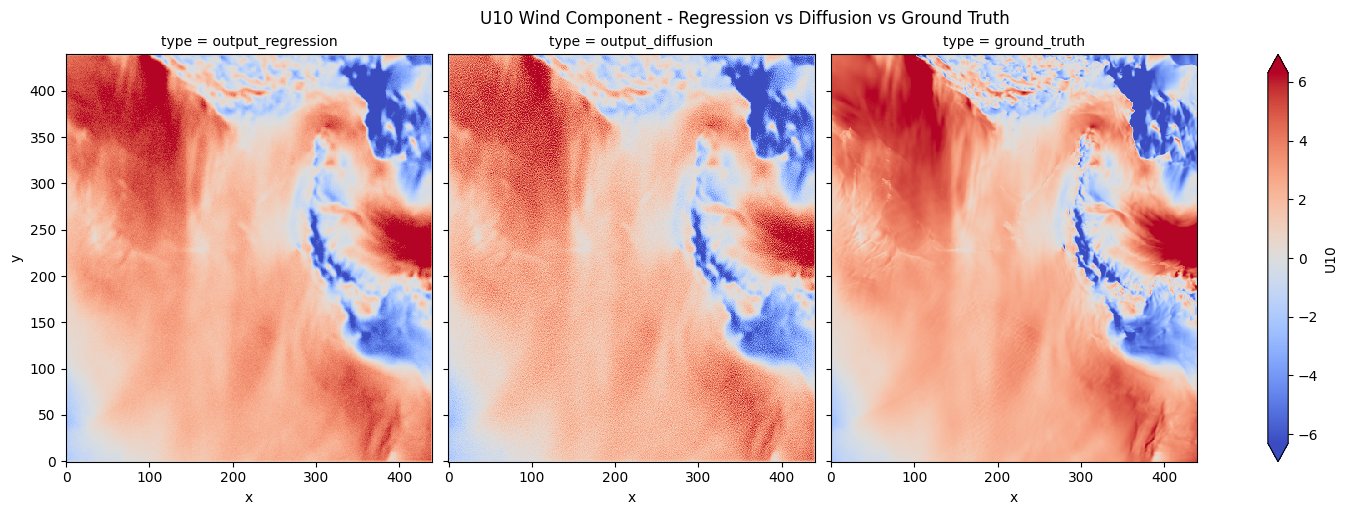


=== V10 Wind Component ===


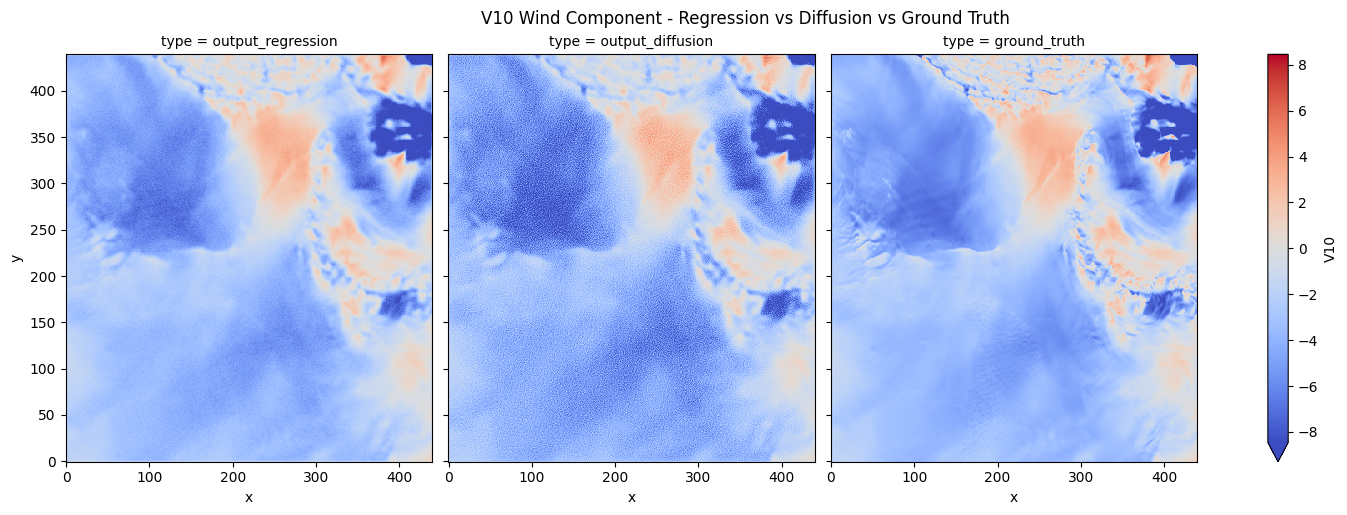

In [6]:
# 1. Load and prepare input data
data_path = ERA5_WRF_COMBINED_CONCATENATED_DIR + "2024-04-30_2024-05-30_21.nc"
stats_path = STAT_DIR + "stat.json"

input_data, output_data = get_data(data_path, sample_idx = 100)

with open(stats_path) as f:
    stats = json.load(f)

# 7. Prepare high-res input (2 channels of zeros as initial guess)
#output_regression = torch.zeros(1, 2, 440, 440)  # For U10/V10 output this came from regression
output_regression = simulate_regression(output_data)

output_diffuse = diffuse(model, input_data, stats, output_regression, iteration=1)
    
output_diffuse = output_diffuse.cpu().numpy()

plot_results_xarray(output_regression, output_diffuse, output_data, stats)


U10 Prediction vs Ground Truth:
Diffuse Pred mean: 1.5887, True mean: 1.7110
Diffuse Pred std: 2.7721, True std: 2.8602
Regression Pred mean: 1.7057
Regression Pred std: 2.8005

V10 Prediction vs Ground Truth:
Diffuse Pred mean: -3.9764, True mean: -2.9363
Diffuse Pred std: 2.8158, True std: 2.4928
Regression Pred mean: -2.9222
Regression Pred std: 2.4313

=== U10 Wind Component ===


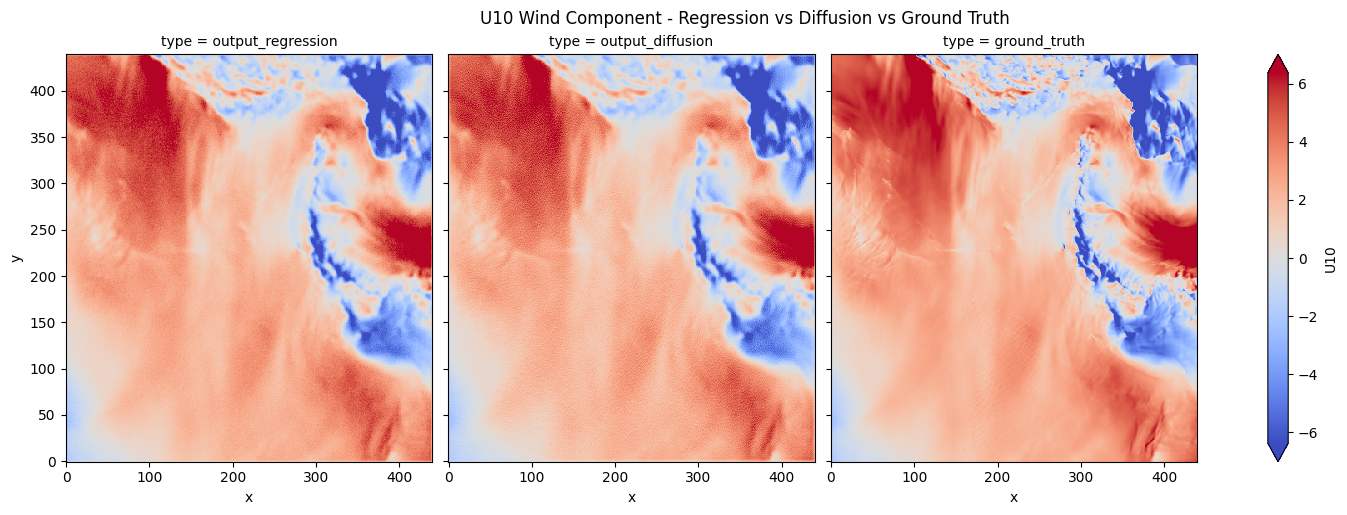


=== V10 Wind Component ===


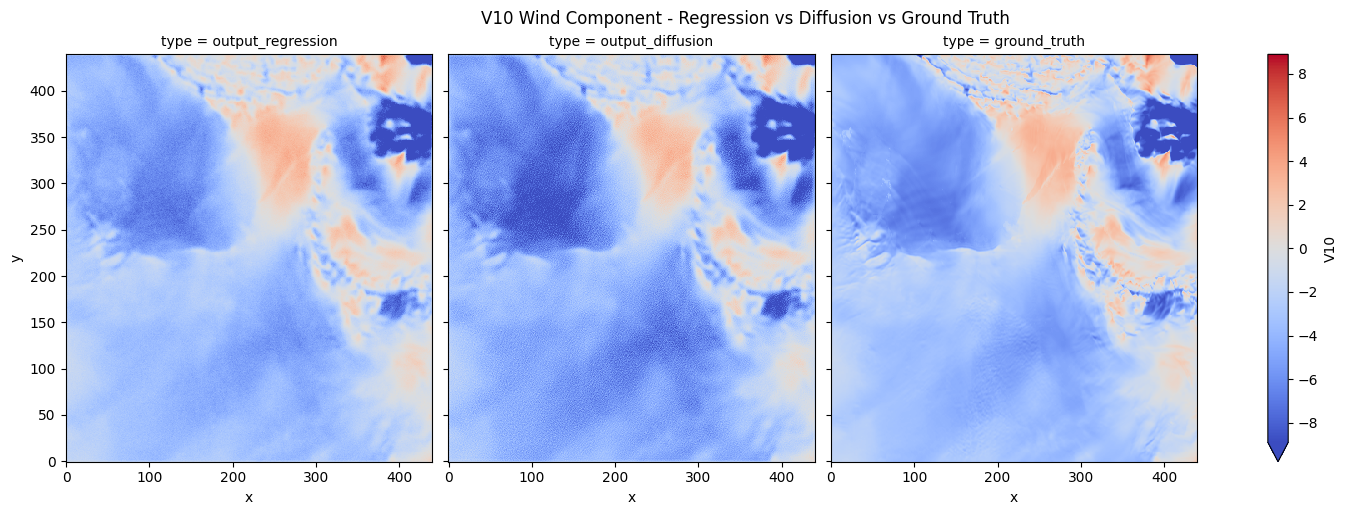

In [101]:
plot_results_xarray(output_regression, output_diffuse, output_data)